In [44]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix
)

# Model
from xgboost import XGBClassifier

# Saving
import joblib
import os

In [45]:
df = pd.read_csv("../data/processed/tmdb_clean.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (16718, 26)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,ROI,profitable
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",5.159580,1
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",4.252904,1
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",5.430046,1
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",12.336312,1
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",6.903707,1


In [46]:
# Target
y = df["profitable"]


# Release Date Features
df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year
df["release_month"] = pd.to_datetime(df["release_date"], errors="coerce").dt.month

df["is_summer"] = df["release_month"].isin([5,6,7]).fillna(False).astype(int)
df["is_holiday"] = df["release_month"].isin([11,12]).fillna(False).astype(int)


# Budget Features
df["log_budget"] = np.log1p(df["budget"].fillna(0))
df["budget_runtime_ratio"] = df["budget"].fillna(0) / (df["runtime"].fillna(1) + 1)

df["budget_bucket"] = pd.qcut(
    df["budget"].fillna(0),
    q=5,
    labels=False,
    duplicates="drop"
)

df["budget_percentile"] = df["budget"].fillna(0).rank(pct=True)


# Runtime Feature

df["long_movie"] = (df["runtime"].fillna(0) > 120).astype(int)

# Count Features

df["genre_count"] = df["genres"].fillna("").apply(lambda x: len(str(x).split(",")))
df["company_count"] = df["production_companies"].fillna("").apply(lambda x: len(str(x).split(",")))
df["country_count"] = df["production_countries"].fillna("").apply(lambda x: len(str(x).split(",")))


# Release Decade
df["release_decade"] = (df["release_year"].fillna(0) // 10) * 10


# Structural Indicators
df["is_sequel"] = (
    df["title"]
    .fillna("")
    .str.contains(r"\d|II|III|IV|V|Part", regex=True)
).astype(int)

df["is_major_studio"] = (
    df["production_companies"]
    .fillna("")
    .str.contains("Warner|Universal|Disney|Paramount|Sony|Fox", case=False, regex=True)
).astype(int)

df["is_english"] = (
    df["spoken_languages"]
    .fillna("")
    .str.contains("en", case=False)
).astype(int)

df["has_homepage"] = df["homepage"].notnull().astype(int)

# new — Popularity Feature

df["log_popularity"] = np.log1p(df["popularity"].fillna(0))

In [47]:
numerical_features = [
    "log_budget",
    "budget_runtime_ratio",
    "budget_percentile",
    "runtime",
    "release_year",
    "is_summer",
    "is_holiday",
    "long_movie",
    "genre_count",
    "company_count",
    "country_count",
    "is_sequel",
    "is_major_studio",
    "is_english",
    "has_homepage",
    "log_popularity"   # NEW
]

categorical_features = [
    "genres",
    "production_companies",
    "production_countries",
    "budget_bucket",
    "release_decade"
]

X = df[numerical_features + categorical_features]

print("X shape:", X.shape)
print("Class balance:\n", y.value_counts())

X shape: (16718, 21)
Class balance:
 profitable
0    10907
1     5811
Name: count, dtype: int64


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [52]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_estimators=800,
    learning_rate=0.04,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=1,
    gamma=0.15,
    reg_lambda=2.0,
    scale_pos_weight=1.1,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV ROC-AUC:", cv_auc.mean())

CV ROC-AUC: 0.7470653267734908


In [54]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [55]:
y_val_proba = cross_val_predict(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_val_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.27878094


In [56]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("TEST Accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST Precision:", precision_score(y_test, y_test_pred))
print("TEST Recall:", recall_score(y_test, y_test_pred))
print("TEST F1:", f1_score(y_test, y_test_pred))
print("TEST ROC-AUC:", roc_auc_score(y_test, y_test_proba))

TEST Accuracy: 0.6342703349282297
TEST Precision: 0.4841228526808954
TEST Recall: 0.8003442340791739
TEST F1: 0.6033084657800843
TEST ROC-AUC: 0.7597267425075449


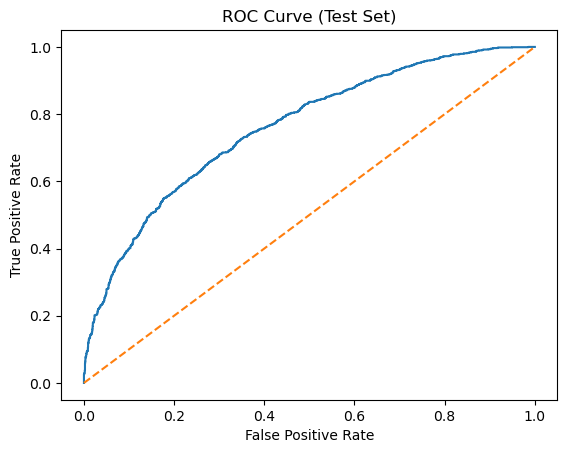

In [57]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

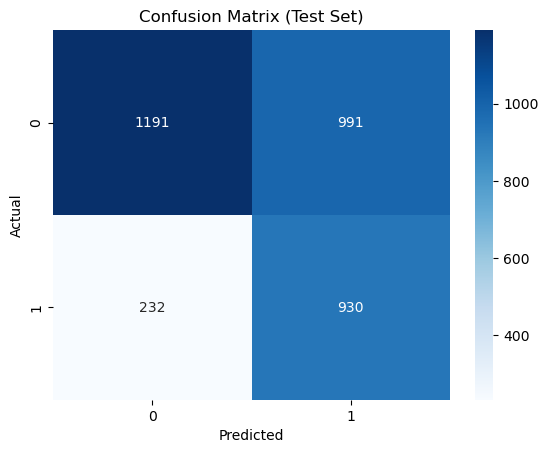

In [58]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [59]:
# Create folder if it doesn't exist
os.makedirs("./artifacts", exist_ok=True)

# Save the full pipeline
joblib.dump(pipeline, "./artifacts/final_model_with_popularity.pkl")

print("Model saved successfully.")

Model saved successfully.
